In [2]:
import pandas as pd

url1= "D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/IH_Project-3/covid.csv"  # Data from Kaggel (vaccines)
df = pd.read_csv(url1)



url2="D:/04_IronHack_DA/IRONHACK_LABS_PROJECTS/IH_Project-3/df_death_rate.csv" #Data from API (death rate, recovery rate)
df_death_rate = pd.read_csv(url2)


In [ ]:
df_location_vaccine = df[["location", "vaccines"]] # created a new dataframe from the kaggel dataframe with columns location and vaccines

df_location_vaccine["vaccine_count"] = df_location_vaccine["vaccines"].apply(lambda x : len(x.split(","))) # created a new column "vaccine_count" by splitting with commas and counting the number of vaccined for each country


df_location_vaccine.to_csv(r"D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\df_location_vaccine.csv")
df_location_vaccine


In [33]:
df_merged = pd.merge(df_death_rate, df_location_vaccine, left_on="country", right_on="location", how = "inner") # merged the API data and the kaggel data on country names




df_merged.to_csv(r"D:\04_IronHack_DA\IRONHACK_LABS_PROJECTS\IH_Project-3\df_merged.csv")
df_merged.columns

Index(['Unnamed: 0', 'updated', 'country', 'countryInfo', 'cases',
       'todayCases', 'deaths', 'todayDeaths', 'recovered', 'todayRecovered',
       'active', 'critical', 'casesPerOneMillion', 'deathsPerOneMillion',
       'tests', 'testsPerOneMillion', 'population', 'continent',
       'oneCasePerPeople', 'oneDeathPerPeople', 'oneTestPerPeople',
       'activePerOneMillion', 'recoveredPerOneMillion',
       'criticalPerOneMillion', 'location', 'vaccines', 'vaccine_count'],
      dtype='object')

In [53]:
def bucket(x):   # Function for grouping the countries based on their vaccine counts
    if x<=2:
        return "1-2 vaccines"
    elif x <=5:
        return "3-5 vaccines"
    else:
        return "6+ vaccines"

df_merged["vaccine_group"]=df_merged["vaccine_count"].apply(bucket)
print(df_merged["vaccine_group"].value_counts())

    
result=df_merged.groupby("vaccine_group")["deathsPerOneMillion"].mean()
display(result)

# group sizes are unequal and results may be influence by factors like healthcare infrastructure and country wealth.


vaccine_group
3-5 vaccines    94
1-2 vaccines    55
6+ vaccines     45
Name: count, dtype: int64


vaccine_group
1-2 vaccines     730.909091
3-5 vaccines    1596.351064
6+ vaccines     1226.266667
Name: deathsPerOneMillion, dtype: float64

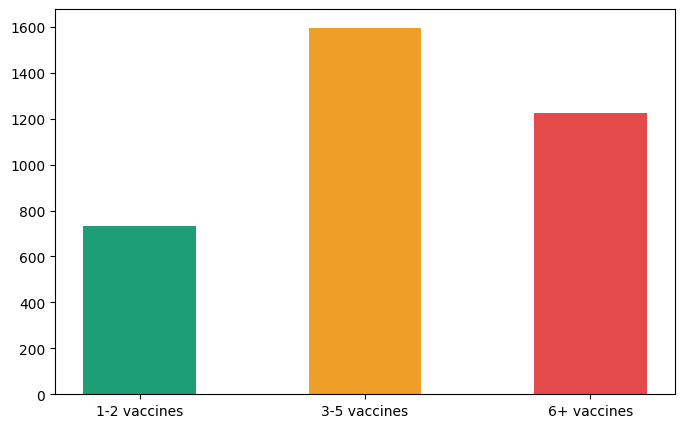

In [55]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))

bars = plt.bar(result.index, result.values, color=['#1D9E75', '#EF9F27', '#E24B4A'], width=0.5)